In [1]:
import sys
from pathlib import Path
import pickle
import numpy as np

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from src.second_encoding import SecondEncoder
from src.quantum.state_construction import StateConstructionBuilder
from src.quantum.swap_test import SwapTestBuilder

In [2]:
with open(
    PROJECT_ROOT / "outputs" / "project_data.pkl",
    "rb",
) as f:

    project_data = pickle.load(f)

In [3]:
with open(
    PROJECT_ROOT /
    "outputs" /
    "candidate_evaluation" /
    "matched_candidates.pkl",
    "rb",
) as f:

    matched_candidates = pickle.load(f)

In [4]:
ligand_interactions = tuple(

    (
        row["Hydrophobic"],
        row["Hydrogen_Bond"],
    )

    for _, row in project_data.ligand.iterrows()

)

In [5]:
encoder = SecondEncoder(
    project_data.interaction_ranges
)

candidate = matched_candidates[0]

encoding_result = encoder.build(
    candidate,
    ligand_interactions,
)

In [6]:
builder = StateConstructionBuilder()

state_result = builder.build(
    encoding_result
)

In [7]:
swap_builder = SwapTestBuilder()

qc = swap_builder.build(
    state_result
)

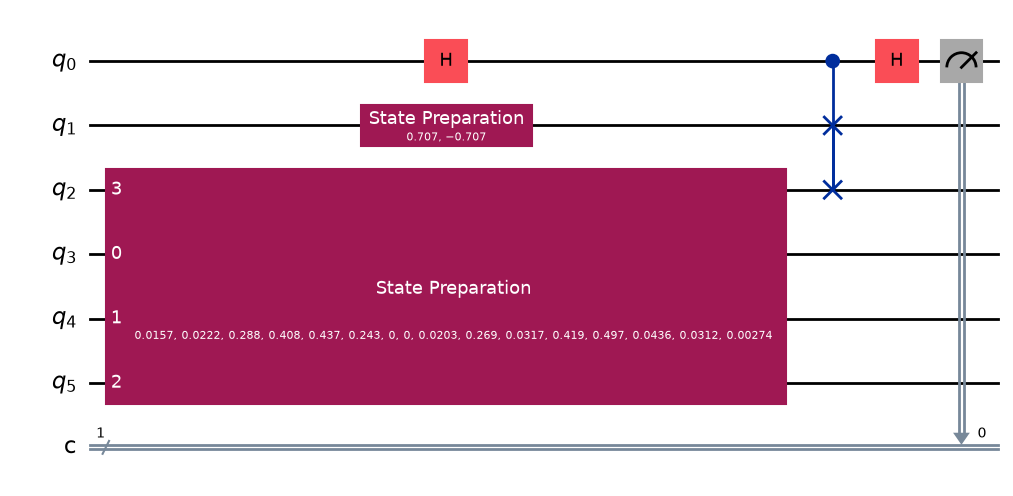

In [8]:
qc.draw(
    "mpl",
    fold=1,
)

In [9]:
print("Number of qubits :", qc.num_qubits)

print("Depth :", qc.depth())

print("Size :", qc.size())

print("Operations")

print(qc.count_ops())

Number of qubits : 6
Depth : 4
Size : 6
Operations
OrderedDict({'state_preparation': 2, 'h': 2, 'cswap': 1, 'measure': 1})


In [10]:
from qiskit.quantum_info import Statevector

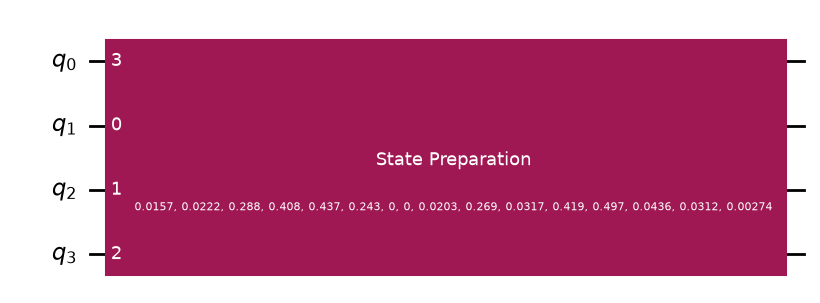

In [11]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

psi = state_result.psi_state

n = int(np.log2(len(psi))) - 1

anc1 = 0
data = list(range(1, n + 1))

qc = QuantumCircuit(n + 1)

qc.append(
    StatePreparation(psi),
    data + [anc1]
)

qc.draw("mpl")

In [12]:
sv = Statevector.from_instruction(qc)

In [13]:
sv.draw("latex")

<IPython.core.display.Latex object>

In [14]:
psi

array([0.01569451, 0.02221173, 0.28810641, 0.40774382, 0.43674049,
       0.24342913, 0.        , 0.        , 0.02033838, 0.26948353,
       0.0316588 , 0.41947908, 0.49710688, 0.04363915, 0.03119102,
       0.00273814])

In [15]:
import numpy as np

np.allclose(
    sv.data,
    psi
)

False

In [16]:
from qiskit.quantum_info import Statevector
import numpy as np

sv = Statevector.from_instruction(qc)

print("Expected:")
print(np.round(psi, 6))

print()

print("Prepared:")
print(np.round(sv.data, 6))

Expected:
[0.015695 0.022212 0.288106 0.407744 0.43674  0.243429 0.       0.
 0.020338 0.269484 0.031659 0.419479 0.497107 0.043639 0.031191 0.002738]

Prepared:
[0.015695+0.j 0.020338-0.j 0.022212+0.j 0.269484-0.j 0.288106-0.j
 0.031659-0.j 0.407744-0.j 0.419479-0.j 0.43674 +0.j 0.497107+0.j
 0.243429-0.j 0.043639-0.j 0.      +0.j 0.031191-0.j 0.      +0.j
 0.002738+0.j]


In [17]:
np.allclose(
    np.sort(psi),
    np.sort(sv.data)
)

True

In [18]:
print(np.max(np.abs(sv.data - psi)))

0.4971068769976077


In [19]:
print(np.allclose(sv.data, psi))
print(np.max(np.abs(sv.data - psi)))

False
0.4971068769976077


In [22]:
for i, (expected, prepared) in enumerate(zip(psi, sv.data)):
    if not np.isclose(expected, prepared):
        print(f"{i:2d}: expected={expected:.6f}, prepared={prepared:.6f}")

 1: expected=0.022212, prepared=0.020338-0.000000j
 2: expected=0.288106, prepared=0.022212+0.000000j
 3: expected=0.407744, prepared=0.269484-0.000000j
 4: expected=0.436740, prepared=0.288106-0.000000j
 5: expected=0.243429, prepared=0.031659-0.000000j
 6: expected=0.000000, prepared=0.407744-0.000000j
 7: expected=0.000000, prepared=0.419479-0.000000j
 8: expected=0.020338, prepared=0.436740+0.000000j
 9: expected=0.269484, prepared=0.497107+0.000000j
10: expected=0.031659, prepared=0.243429-0.000000j
11: expected=0.419479, prepared=0.043639-0.000000j
12: expected=0.497107, prepared=0.000000+0.000000j
13: expected=0.043639, prepared=0.031191-0.000000j
14: expected=0.031191, prepared=0.000000+0.000000j


In [20]:
# psi = np.arange(16, dtype=float)
# psi /= np.linalg.norm(psi)

In [21]:
# qc = QuantumCircuit(4)
# qc.append(StatePreparation(psi), [0, 1, 2, 3])

# sv = Statevector.from_instruction(qc)


# print("Expected:")
# print(np.round(psi, 6))

# print("Prepared:")
# print(np.round(sv.data, 3))